## Исследование данных о российском кинопрокате



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
mkrf_movies = pd.read_csv('/datasets/mkrf_movies.csv')
mkrf_shows = pd.read_csv('/datasets/mkrf_shows.csv')
mkrf_movies.info()
mkrf_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

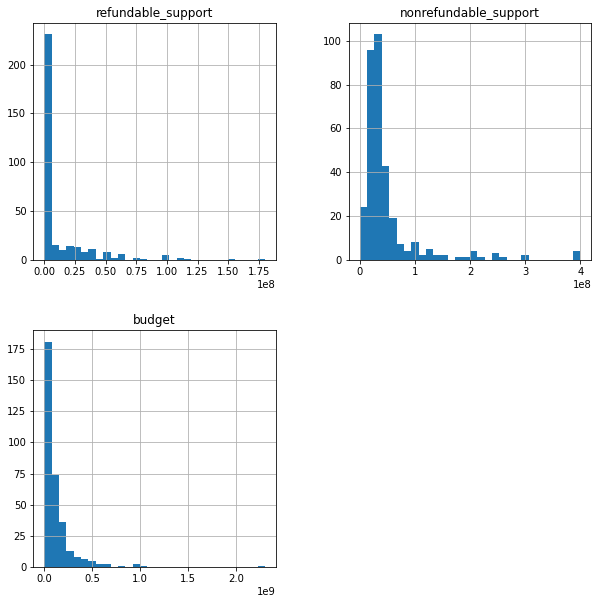

<AxesSubplot:>

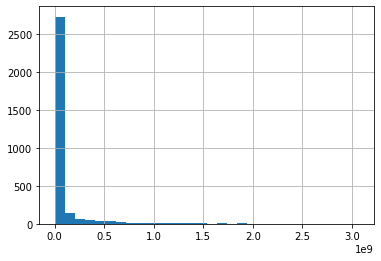

In [2]:
mkrf_movies.hist(bins=30, figsize=(10,10))
plt.show()
mkrf_shows['box_office'].hist(bins=30)

В данных можно увидеть следующие проблемы:
- пропуски (в категориальных и количественных значениях)
- неверные типы данных (дата премьеры с типом object, рейтинг с типом object и тд)

По гистограммам можно заметить, что количественные данные в основном имеют нормальное распределение, есть некоторые "выбивающиейся" значения, но они не будут являться аномальными, тк в этой сферы суммы общих сборов/бюджет могут быть любыми.

### 1 Загрузка данных

In [3]:
mkrf_movies['puNumber'] = pd.to_numeric(mkrf_movies['puNumber'], errors='coerce')
mkrf_shows['puNumber'] = mkrf_shows['puNumber'].astype('int')
data = mkrf_movies.merge(mkrf_shows, on='puNumber', how='left')
data.info()
len(data)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7485 non-null   float64
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

7486

Изменила тип данных в столбце puNumber таблицы mkrf_shows(с object на float), объединила таблицы mkrf_shows и mkrf_movies по столбцу puNumber. Вывела основную информацию о новой таблице для дальнейшей предобработки данных.

### 2 Предобработка данных

In [4]:
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format='%Y-%m-%dT%H:%M:%S')
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce')

Типы данных были изменены в следующих столбцах:
- дата премьеры фильма (тип данных object на datetime, это необходимо для дальнейшей работы с этим столбцом)
- рейтинг (тип данных object на float); в стобце присутствовали аномальные значения, например "99%", такие значения были заменены на NaN

In [5]:
data = data.dropna(subset=['puNumber', 'director'])
data['puNumber'] = round(data['puNumber'].astype('int'))# после удаления пропусков в столбце изменяю тип данных на int
data.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                17
production_country          1
director                    0
producer                  564
age_restriction             0
refundable_support       7144
nonrefundable_support    7144
budget                   7144
financing_source         7144
ratings                   989
genres                    969
box_office               4319
dtype: int64

Пропуски были обнаружены в следующих столбцах:
- номер прокатного удостоверения (в одном из фильмов номер прокатного удостоверения отсутствовал, такая строка была удалена, тк она не влияет на общую выборку, но затрудняет дальнейший анализ - невозможно узнать количество сборов)
- студия-производитель (пропуски оставлены, так как их невозможно чем-то заполнить)
- страна-производитель (пропуски оставлены, так как их невозможно чем-то заполнить)
- режиссер (пропуски оставлены, так как их невозможно чем-то заполнить)
- продюсер (пропуски оставлены, так как их невозможно чем-то заполнить)
- объем возвратных средств государственной поддержки (пропуски оставлены без изменений, так как пропуск означает отсутствие гос.поддержки)
- объем невозвратных средств государственной поддержки (пропуски оставлены без изменений, так как пропуск означает отсутствие гос.поддержки)
- общий бюджет фильма (пропуски оставлены без изменений, так как пропуск означает отсутствие гос.поддержки)
- рейтинг фильма (пропуски оставлены, так как их невозможно чем-то заполнить)
- жанр фильма (пропуски оставлены, так как недостаточно данных для их заполнения)
- сборы в рублях (пропуски оставлены, так как их невозможно чем-то заполнить)

In [25]:
data = data.drop_duplicates() # удаляем явные дубликаты
data = data.drop_duplicates(subset=['puNumber']) # удаляем дубликаты номеру прокатного удостоверения

Дубликаты в данных:
- явные дубликаты (могли возникнуть в данных из-за ошибки при подгрузке данных)
- дубликаты в номерах прокатного удостоверения (такие данные являются дубликатами, так как каждому фильму могут соотвествовать несколько номеров прокатного удостоверения, но они должны быть уникальны)

Повторяющиеся названия фильмов дубликатами не являются, так как у одного фильма может быть несколько прокатных удостоверений.

In [37]:
data['type'] = data['type'].str.strip()
print(data['type'].unique())
data['production_country'] = data['production_country'].str.replace(' - ', ', ')
data['production_country'] = data['production_country'].str.replace('-', ', ') 
data['production_country'].unique()

['Художественный' 'Анимационный' 'Прочие' 'Документальный'
 'Научно-популярный' 'Музыкально-развлекательный']


array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия, Великобритания', 'Великобритания, Италия',
       'Чехословакия', 'США, Франция, Турция', 'Новая Зеландия',
       'Канада, Франция, Испания', 'США, Германия', 'США, Великобритания',
       'Великобритания', 'Франция, Мексика, США',
       'Россия, Казахстан, США', 'СССР, Швеция',
       'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания, США, Германия, КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США, Франция', 'США, Япония, Франция, Великобритания',
       'Гонконг, Сингапур, Таиланд, Великобритания', 'США, Канада',
       'Франция, Италия, Великобритания, США', 'Франция, США',
       'Ирландия, Великобритания, Германия', 'Чехия', 'США, Австралия',
       'СССР, Финляндия', 'США, Франция, Великобритания, Австрия',
       'США, Бельгия', 'США, Ирландия, Великобритания',
       'Великобритания, США',
       'Люксембург, Нидерланды, Испания, Великобритания,

Проблемы в категориальных значениях:
- неявные дубликаты в столбце "страна-производитель" (" - " было заменено на пробелы)
- неявные дубликаты в столбце "тип фильма" (были убраны пробелы перед значением)

В остальных категориальных значениях проблем нет.

In [8]:
data['is_true'] = (data['nonrefundable_support'] + data['refundable_support']) <= data['budget']
print(data['is_true'].value_counts())
data.loc[data['is_true'] == False,'budget'] = data['nonrefundable_support'] + data['refundable_support']
data['budget'].sort_values()

False    7159
True      315
Name: is_true, dtype: int64


2874     6000000.0
3139    14462464.0
7042    15010000.0
5576    18166418.0
3711    18706080.0
           ...    
7481           NaN
7482           NaN
7483           NaN
7484           NaN
7485           NaN
Name: budget, Length: 7474, dtype: float64

В количественных значениях обнаружены следующие проблемы:

- столбец budget включает в себя полный объем государственной поддержки, следовательно, он должен быть равен или превышать сумму столбцов "refundable_support" и "nonrefundable_support". Я создала столбец 'is_true' для того, чтобы проверить, для скольких столбцов вышеописанное условие выполняется. Вышло, что это условие не выполняется для 7161 строки (вычитаем 7144 строки с NaN, для которых сравнение показывает False автоматически и получаем 17 строк с аномалиями), для них было принято решение заменить значение столбца budget на сумму "refundable_support" и "nonrefundable_support". Благождаря этому действию также заменились нулевые значения стобца "budget", такие значения являлись аномальными.

In [9]:
data['year'] = data['show_start_date'].dt.year

In [10]:
data['director'] = data['director'].astype('str') # меняем тип object на str для последуюего применения функции split
data['genres'] = data['genres'].astype('str') # меняем тип object на str для последуюего применения функции split
def first_name(d):
    first_name = d.split(',')
    return first_name[0]
data['main_director'] = data['director'].apply(first_name)
data['first_genre'] = data['genres'].apply(first_name) 

In [11]:
data['share_of_support'] = (data['nonrefundable_support'] + data['refundable_support']) / data['budget']

Минимальный процент госудаственной поддержки от общего бюджета - 4-7%; максимальный - 100% (фильм полностью финансируется государством).

### 3 Исследовательский анализ данных


<AxesSubplot:xlabel='year'>

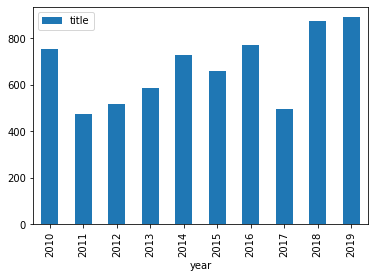

In [12]:
data_films = data.drop_duplicates(subset=['title']) # таблица с уникальными значениями названий фильмов
data_films.pivot_table(index='year', values='title', aggfunc='count').plot(kind='bar')

Больше всего фильмов вышло в прокат в 2018-2019, меньше всего - в 2011-2013, а также в 2017 гг. Следовательно, период 2018-2019 гг полнее всего представлен в данных.

         sum   count dynamics_percent
     is_kino is_kino                 
year                                 
2010      88     756        11.640212
2011      98     475        20.631579
2012     115     516        22.286822
2013     176     589        29.881154
2014     257     729        35.253772
2015     431     661        65.204236
2016     501     771        64.980545
2017     356     498        71.485944
2018     472     875        53.942857
2019     522     891        58.585859


/tmp/ipykernel_48/925281270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_films['is_kino'] = data_films['box_office'].notna()


<AxesSubplot:xlabel='year'>

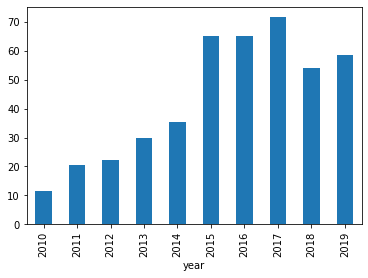

In [13]:
# доля фильмов с указанной информацией о прокате в кинотеатрах (в процентах)
data_films['is_kino'] = data_films['box_office'].notna()
kino = data_films.pivot_table(index='year', values='is_kino', aggfunc=['sum', 'count'])
kino['dynamics_percent'] = (kino['sum'] / kino['count']) * 100
print(kino)
kino['dynamics_percent'].plot(kind='bar')

С 2010 по 2019 наблюдается увеличение числа фильмов, показываемых в кинотеатрах, от общего числа фильмов. С 2015 года больше половины фильмов, выходящих в прокат, показывались в кинотеатрах. Это можно объяснить увеличением популярности кинотеатров, роста числа кинотеатров в городах России. Создатели фильмов заинтересованы в показах на больших экранах с целью получения дополнительной прибыли и известности.

- Изучите, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?

,box_office
year,
2010,2.428654e+06
2011,1.410276e+07
2012,6.911073e+06
2013,2.979971e+07
2014,7.444952e+09
2015,3.949737e+10
2016,4.786630e+10
2017,4.856371e+10
2018,4.966840e+10


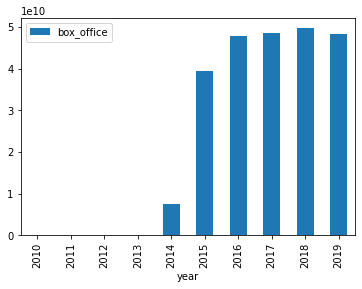

In [14]:
# таблица с суммами сборов за 2010 - 2019 гг
box = data.pivot_table(index='year', values='box_office', aggfunc='sum') 
box.plot(kind='bar')
box

Минамальные суммы сборов были в 2010-2013 гг. С 2014 года сборы постепенно увеличиваются и уже в 2016-2019 гг остаются на примерно одинаково высоких уровнях. Низкие сборы в 2010-2013 гг можно объяснить отсутствием развитой сети кинотеатров (в эти года кинотеатры были только в крупнейших городах России). 

- С помощью сводной таблицы посчитайте среднюю и медианную сумму сборов для каждого года.

In [15]:
data.pivot_table(index='year', values='box_office', aggfunc=['mean', 'median']) 

,mean,median
,box_office,box_office
year,,
2010,2.313004e+04,1700.000
2011,1.293832e+05,3000.000
2012,5.441790e+04,5560.000
2013,1.619549e+05,3522.500
2014,2.668442e+07,18160.000
2015,8.494057e+07,4920933.000
2016,9.100057e+07,3846679.410
2017,1.360328e+08,9968340.000


Из таблицы видно, что между медианными и средними значениями сильная разница. Так произошло из-за того, что медианное значение менее подвержено выбросам, чем среднее, следовательно медианное значение более точно описывает ситуацию. 
В 2010 - 2014 годах медианное значение сборов в рублях достаточно низкое, возможно, в эти года еще не появилось единой системы учета таких данных.

- Определите, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да, предположите, с чем это может быть связано.

<AxesSubplot:xlabel='age_restriction'>

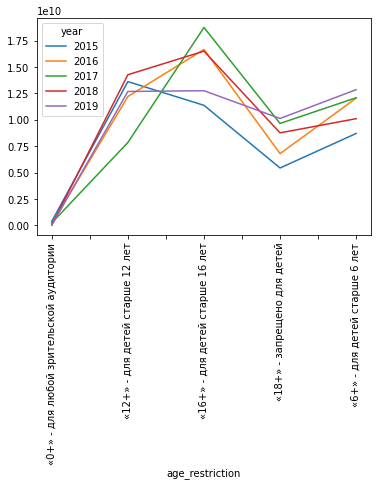

In [16]:
age_data = data.pivot_table(index='age_restriction', columns='year', values='box_office', aggfunc='sum')
age_data = age_data.loc[:, 2015:]
age_data.plot(kind='line', rot=90)

Возрастное ограничение влияет на сборы фильма в прокате: наибольшие сборы у фильмов, возрастной категории "16+", наименьшие - у фильмов возрасной категории "0+". Возможно, это можно объяснить тем, что фильмы возрастной категории "16+" более универсальны - их смотрят и подростки, и взрослые люди. (фильмы "0+", "18+" - специфичны, они для более узкой категории)

В зависимости от года ситуация меняется, но незначительно: в 2016, 2017, 2018 годах наибольшие сборы у фильмов "16+"; в 2015 году наибольшие сборы у фильмов "12+"; в 2019 году сборы по всем возрастным категориям примерно одинаковы (исключая "0+"). Скорее всего, это связано с тем, что в 2015 и в 2019 годах выходили наиболее известные фильмы, которые понравились всем возрастным категориям.

### 4 Исследование фильмов, которые получили государственную поддержку

На этом этапе нет конкретных инструкций и заданий — поищите интересные закономерности в данных. Посмотрите, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

In [17]:
# определяю зависимость наличия господдержки на рейтинг фильмов
data['is_support'] = data['budget'].notna() # создаем новый столбец для разделения фильмы на те, что с господдержкой и без
supported_films = data.pivot_table(index='is_support', values='ratings', aggfunc='median')
supported_films = supported_films.rename(index={False: 'Фильмы без господдержки', True: 'Фильмы с господдержкой'})
supported_films

,ratings
is_support,
Фильмы без господдержки,6.6
Фильмы с господдержкой,6.2


Медианное значение рейтинга у фильмов с господдержкой меньше, чем у фильмов без господдержи. Фильмы с господдержкой меньше нравятся зрителям.

In [18]:
# определяю, на какие возрастные категории фильмов, как правило, выделяется господдержка
age_category_supported_films = data.pivot_table(index='is_support', columns='age_restriction', values='title', aggfunc='count')
age_category_supported_films = age_category_supported_films.rename(index={False: 'Фильмы без господдержки', True: 'Фильмы с господдержкой'})
age_category_supported_films

age_restriction,«0+» - для любой зрительской аудитории,«12+» - для детей старше 12 лет,«16+» - для детей старше 16 лет,«18+» - запрещено для детей,«6+» - для детей старше 6 лет
is_support,,,,,
Фильмы без господдержки,796,1483,2725,1577,561
Фильмы с господдержкой,8,106,125,28,65


В основном, господдержка выделяется на фильмы с возрастными категориями "12+" и "16+", это можно объяснить тем, что в эти возрастные категории входят подрастающие поколения, которым необходимо показать ценности, поддерживаемые государством.

/tmp/ipykernel_48/1525257305.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  film_payback['is_payback'] = data['budget'] < data['box_office']


,title,percent_of_payback
is_payback,,
не окупившиеся фильмы,253,76.204819
окупившиеся фильмы,79,23.795181


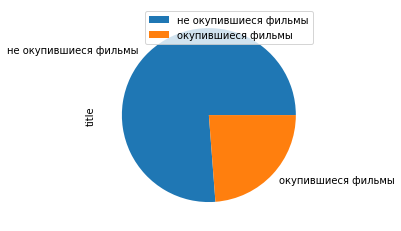

In [19]:
# определяю окупаемость фильмов с господдержкой и без нее
# отделяю фильмы с господдержкой от основной таблицы
film_payback = data.query('is_support == True')
film_payback['is_payback'] = data['budget'] < data['box_office']
payback_count = film_payback.pivot_table(index='is_payback', values='title', aggfunc='count')
payback_count = payback_count.rename(index={False: 'не окупившиеся фильмы', True: 'окупившиеся фильмы'})
payback_count.plot(kind='pie', y='title')
payback_count['percent_of_payback'] = (payback_count['title'] / payback_count['title'].sum()) * 100 
payback_count

24% фильмов с господдержкой окупаются, 76% - не окупаются. Это означает, что фильмы с господдержкой менее интересуют зрителей, возможно из-за того, что фильмы с господдержкой чаще носят образовательный, поучительный характер, что реже интересует молодое поколение, нежели развлекательные фильмы.

In [20]:
# определяю, на фильмы каких жанров, как правило, выделяется господдержка
data[data['is_support'] == True].pivot_table(index='first_genre', values='title', aggfunc='count') \
.sort_values(by='title', ascending=False)

,title
first_genre,
драма,93
комедия,74
мультфильм,31
nan,16
триллер,15
мелодрама,15
фантастика,11
фэнтези,11
ужасы,10


Фильмы с господдержкой в основном следующих жанров: "драма", "комедия", "мультфильм". Такой факт объяснялся в выводах выше - фильмы, финансируемые государством, как правило, имеют образовательные/воспитательные цели и предназначены в основном для подрастающего поколения, поэтому, они обычно сняты в вышеперечисленных жанрах.

### 5 Общий вывод

В качестве исходных данных были переданы две таблицы: первая - содержит информацию из реестра прокатных удостоверения, вторая - содержит сведения о показах фильмов в российских кинотеатрах.
Для более комфортной дальнейшей работы эти таблицы были объединены в одну по номеру прокатного удостоверения.

**В исходных данных были следующие проблемы:**
- неверные типы данных (столбец с датой выхода типа object, рейтинг фильма с типом object);
- явные дубликаты (были удалены из общей выборки);
- пропуски в столбцах "номер прокатного удосторения", "студия-производитель", "страна-производитель", "режиссер", "продюсер", "объем возвратных/невозвратных средств государственной поддержки", "общий бюджет фильма", "рейтинг фильма", "жанр фильма", "сборы в рублях" (пропуски были или удалены, или оставлены без изменения из-за недостаточного количества данных для их заполнения);
- неявные дубликаты в столбцах "страна-производитель" и "тип фильма" (были удалены лишние знаки препинания/пробелы);
- аномальные количественные значения: превышение суммы возвратных и невозвратных значений государственной поддержки над общим бюджетом фильма (такие значения бюджета были заменены на сумму возвратных и невозвратных средств государственной поддержки);

**Для дальнейшего анализа в таблице были созданы следующие столбцы**
- столбец с информацией о годе проката;
- столбец с именем и фамилией главного режиссера и основным жанром фильма;

**В результате анализа были замечены следующие закономерности**

- минимальный процент госудаственной поддержки от общего бюджета - 4-7%; максимальный - 100% (фильм полностью финансируется государством);
- полнее всего в данных представлен период 2018-2019 гг, в это время в прокат вышло больше всего фильмов;
- в весь рассматриваемый период процент фильмов, показываемых в кинотеатрах от общего числа фильмов постепенно увеличивается. с 2015 года больше половины от всех фильмов показываются в кинотеатрах;
- в рассматриваемом периоде сумма сборов в рублях постепенно увеличивается. это можно объяснить увеличением числа кинотеатрах и роста их популярности среди молодого поколения;
- существует зависимость сборов в рублях от возрастной категории - наибольшие сборы у фильмов с возрастной категорий "16+", наименьшие - у фильмов "0+". это можно объяснить тем, что фильмы категории "16+" более универсальны, их смотрят и подростки, и взрослые люди (фильмы "18+" более специфичны, поэтому у таких фильмов сборы меньше);
  
**Закономерности в фильмах с господдержкой**

- медианный рейтинг фильмов с господдержкой меньше, чем у фильмов без господдержки (разница между рейтингами составляет 0,5);
- господдержка в основном выделяется на фильмы с возрастными категорими "12+" и "16+", это объяснино тем, что в основном финансово поддерживаются фильмы, направленные на воспитание подрастающего поколения;
- 24% фильмов с господдержкой окупаются, 76% - не окупаются. из этого можно сделать вывод, что фильмы, финансируемые государством, меньше интересуют зрителей;
- фильмы с господдержкой в основном следующих жанров: "драма", "комедия", "мультфильм";

**Рекомендации**

- стоит изучить причины возникновения пропусков в данных, предотвратить последующие;
- изменить принцип заполнения столбцов с категориальными значениями, предотвратить последующие неявные дубликаты в стобцах "страна-производитель", "тип фильма" и др.;
- обратить внимание на аномальные значения (аномальные значения были в столбце с общим бюджетом фильма), узнать причину их появления, предотвратить последующие;
- необходимо изучить зависимость суммы сборов в рублях от студии-производителя/режиссера, это поможет прогнозировать, какие фильмы стоит обеспечивать государственной поддержкой или же какие фильмы стоит показывать в кинотеатрах.